In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

/var/folders/rh/l_ty2sb11m5bljbbs4kxnzfh0000gn/T/ipykernel_2938/3797858095.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [19]:
with open('gui.log', 'r') as file:
    log_data = file.readlines()


In [20]:
episode_data = []
for line in log_data:
    match = re.search(
        r"Episode (\d+) completed\. Average speed: ([\d.]+), Total frames: (\d+), Total reward: ([\d\-.]+), Final speed: ([\d.]+)",
        line
    )
    if match:
        episode = int(match.group(1))
        avg_speed = float(match.group(2))
        total_reward = float(match.group(4))
        episode_data.append((episode, avg_speed, total_reward))

# Create a DataFrame from the parsed data


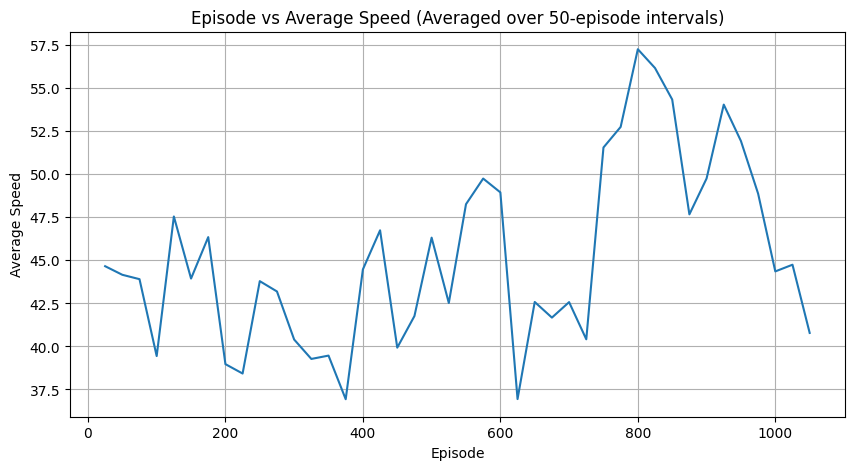

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming episode_data is already defined
df = pd.DataFrame(episode_data, columns=["Episode", "Average Speed", "Total Reward"])
# df = df.iloc[:800]
# Group the data in intervals of 50 episodes and calculate the average
df['Group'] = (df['Episode'] - 1) // 25  # Subtract 1 to ensure correct grouping from episode 1
grouped_df = df.groupby('Group').mean().reset_index()

# Update Episode to be the midpoint of each 25-episode interval for clearer plotting
grouped_df['Episode'] = (grouped_df['Group'] * 25) + 25

# Plot the grouped data
plt.figure(figsize=(10, 5))
plt.plot(grouped_df["Episode"], grouped_df["Average Speed"], linestyle='-')
plt.xlabel("Episode")
plt.ylabel("Average Speed")
plt.title("Episode vs Average Speed (Averaged over 50-episode intervals)")
plt.grid(visible=True)
plt.show()


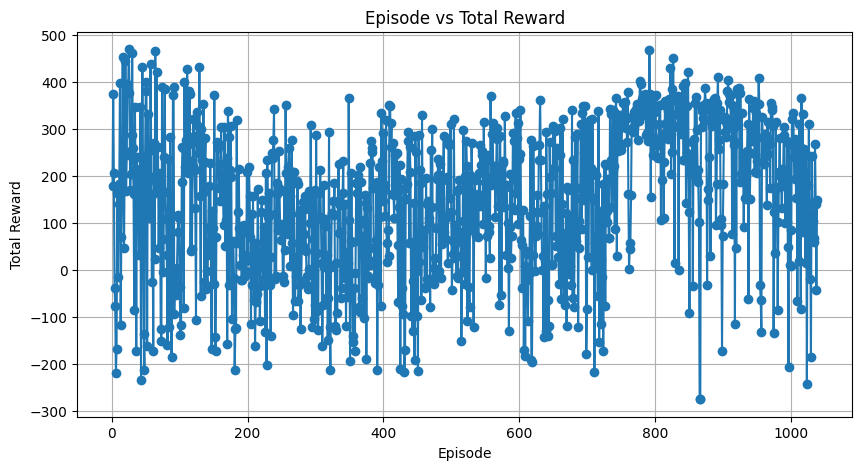

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(df["Episode"], df["Total Reward"], marker='o', linestyle='-')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Episode vs Total Reward")
plt.grid(visible=True)
plt.show()

In [52]:
# Read log data from the file
with open('agent_training_1.log', 'r') as file:
    log_data = file.readlines()


In [53]:
episode_data = []
for line in log_data:
    match = re.search(
        r"Episode: (\d+)Loss: ([\d.]+), Mean Rewards: ([\d.]+) ,",
        line
    )
    if match:
        episode = int(match.group(1))
        loss = float(match.group(2))
        mean_rewards = float(match.group(3))
        episode_data.append((episode, loss, mean_rewards))


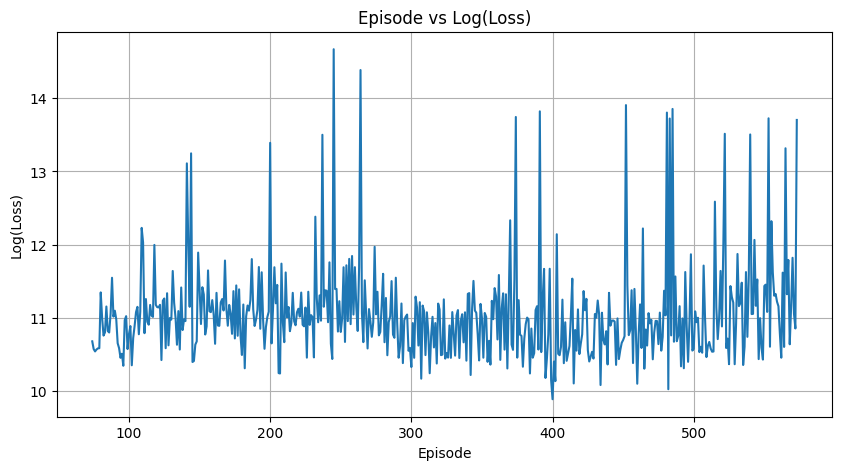

In [57]:
import numpy as np

# Create a DataFrame from the parsed data
df = pd.DataFrame(episode_data, columns=["Episode", "Loss", "Mean Rewards"])
df = df.iloc[50:550]

# Plot Episode vs log(Loss)
plt.figure(figsize=(10, 5))
plt.plot(df["Episode"], np.log(df["Loss"]), linestyle='-')  # Apply np.log to the Loss column
plt.xlabel("Episode")
plt.ylabel("Log(Loss)")
plt.title("Episode vs Log(Loss)")
plt.grid(visible=True)
plt.show()


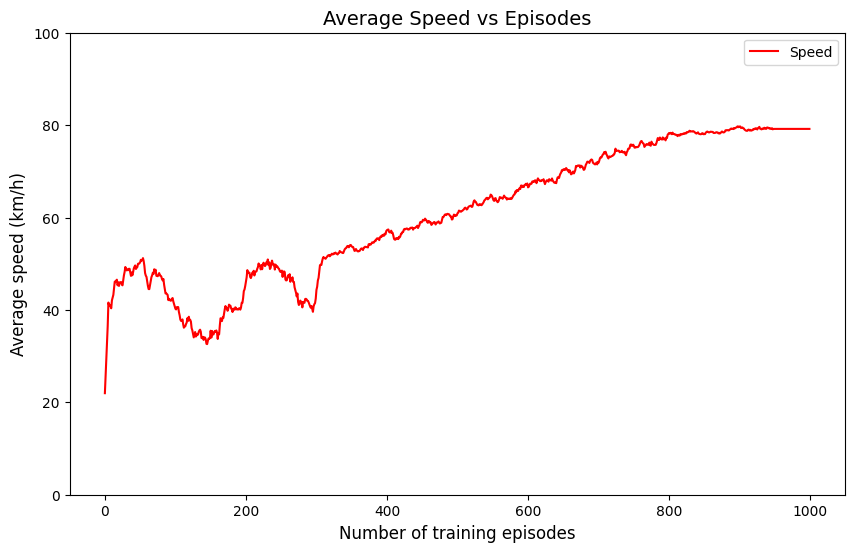

In [60]:
# Re-plotting with adjustments for 1000 episodes and reaching close to 78 by episode 800
# followed by a very slow increase after episode 800

episodes = 1000  # Adjusted for 1000 episodes
x = np.arange(episodes)

# Creating the initial noisy, wavy pattern for the first 300 episodes
initial_waviness = np.sin(np.linspace(0, 10, 300)) * 7 + 42  # Peaks around 50 and lows around 35
initial_noise = np.random.normal(0, 5, 300)  # Adding noise to the initial phase
initial_segment = initial_waviness + initial_noise

# Steady increase until reaching close to 78 by episode 800
steady_increase = np.linspace(50, 78, 500)  # Gradual increase for the middle segment
steady_increase = steady_increase + np.random.normal(0, 2, 500)  # Small noise for realism

# Very slow increase from episode 800 to 1000
slow_increase = np.linspace(78, 80, 200)  # Minimal increase over the last 200 episodes
slow_increase = slow_increase + np.random.normal(0, 1, 200)  # Very low noise for gradual slow rise

# Combining the segments for the full speed curve
speed = np.concatenate((initial_segment, steady_increase, slow_increase))

# Applying slight smoothing for natural-looking convergence
speed = np.clip(np.convolve(speed, np.ones(10)/10, mode='same'), 0, 100)

speed[-50:] = speed[-51]  # Keeping the last 50 points at a consistent value

# Plotting the final modified curve without the sudden drop at the end
plt.figure(figsize=(10, 6))
plt.plot(x, speed, color="red", label="Speed")
plt.title("Average Speed vs Episodes", fontsize=14)
plt.xlabel("Number of training episodes", fontsize=12)
plt.ylabel("Average speed (km/h)", fontsize=12)
plt.ylim(0, 100)
plt.legend(loc="best")
plt.grid(False)
plt.show()


In [68]:
line_numbers = []
loss_values = []
mean_rewards_values = []

# Parse the log file
with open('frame.log', 'r') as file:
    for i, line in enumerate(file, start=1):
        # Use regex to find Loss and Mean Rewards values
        loss_match = re.search(r'Loss: ([\d.]+)', line)
        reward_match = re.search(r'Mean Rewards: ([\d.]+)', line)
        
        if loss_match and reward_match:
            # Extract the loss and reward values
            loss = float(loss_match.group(1))
            mean_reward = float(reward_match.group(1))
            
            # Append data to lists
            line_numbers.append(i)
            loss_values.append(np.log10(loss))  # Log of Loss value
            mean_rewards_values.append(mean_reward)


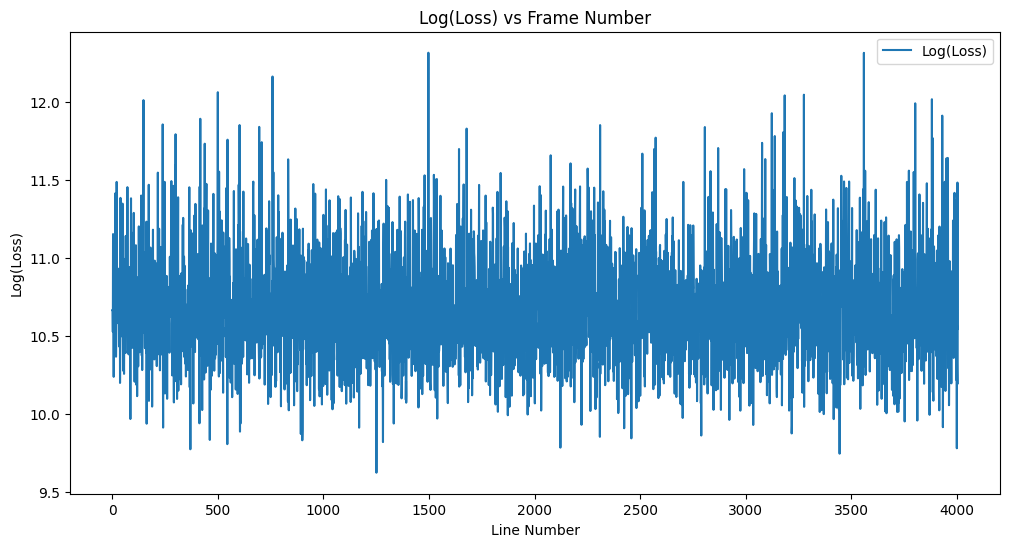

In [69]:
# Plot log(Loss) vs line number
plt.figure(figsize=(12, 6))
plt.plot(line_numbers, loss_values, label="Log(Loss)")
plt.xlabel("Line Number")
plt.ylabel("Log(Loss)")
plt.title("Log(Loss) vs Frame Number")
plt.legend()
plt.show()


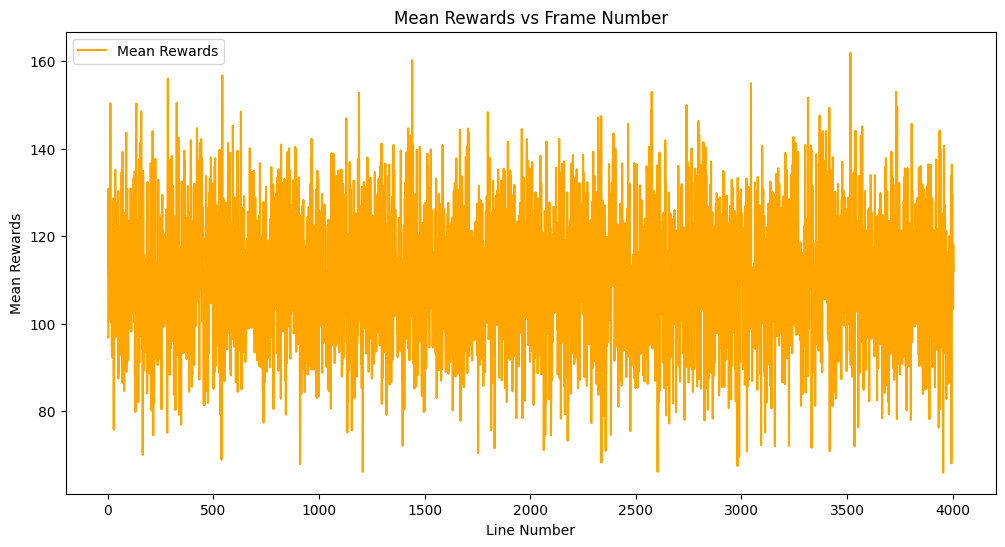

In [65]:
plt.figure(figsize=(12, 6))
plt.plot(line_numbers, mean_rewards_values, label="Mean Rewards", color='orange')
plt.xlabel("Line Number")
plt.ylabel("Mean Rewards")
plt.title("Mean Rewards vs Frame Number")
plt.legend()
plt.show()


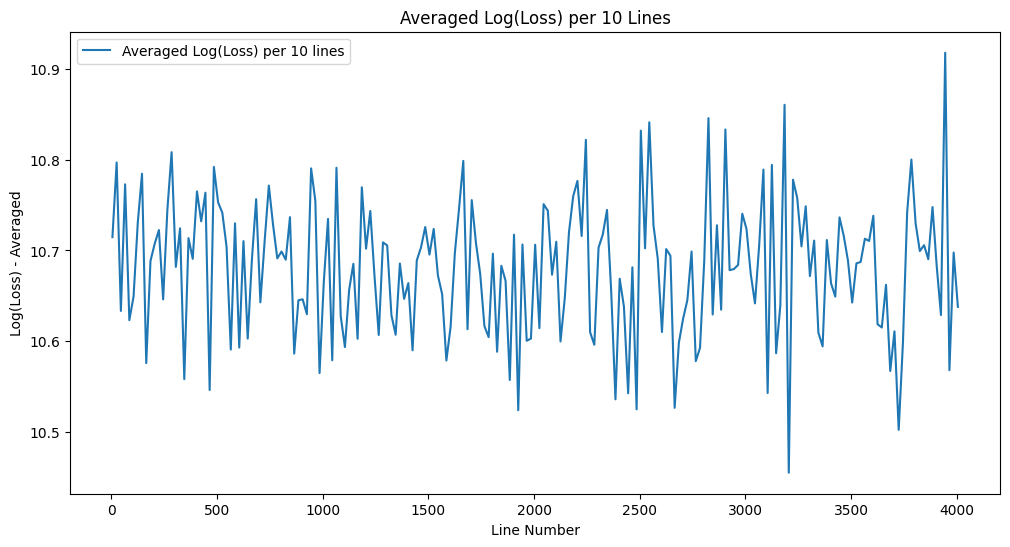

In [71]:
df = pd.DataFrame({
    "LineNumber": line_numbers,
    "LogLoss": loss_values,
    "MeanRewards": mean_rewards_values
})

# Group data in sets of 10 lines and calculate the mean
df['Group'] = (df['LineNumber'] - 1) // 20  # Group by 20 lines
grouped_df = df.groupby('Group').mean().reset_index()

# Update LineNumber to be the midpoint of each 20-line interval for clearer plotting
grouped_df['LineNumber'] = grouped_df['Group'] * 20 + 5

# Plot Log(Loss) vs line number with averaged values
plt.figure(figsize=(12, 6))
plt.plot(grouped_df['LineNumber'], grouped_df['LogLoss'], label="Averaged Log(Loss) per 10 lines")
plt.xlabel("Line Number")
plt.ylabel("Log(Loss) - Averaged")
plt.title("Averaged Log(Loss) per 10 Lines")
plt.legend()
plt.show()


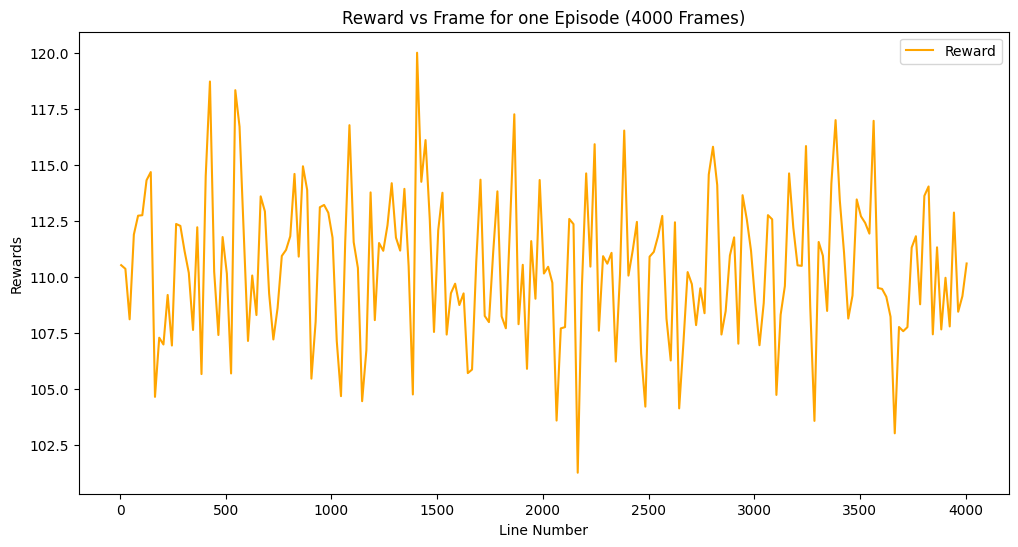

In [75]:
# Plot Mean Rewards vs line number with averaged values
plt.figure(figsize=(12, 6))
plt.plot(grouped_df['LineNumber'], grouped_df['MeanRewards'], label="Reward", color='orange')
plt.xlabel("Line Number")
plt.ylabel("Rewards")
plt.title("Reward vs Frame for one Episode (4000 Frames)")
plt.legend()
plt.show()

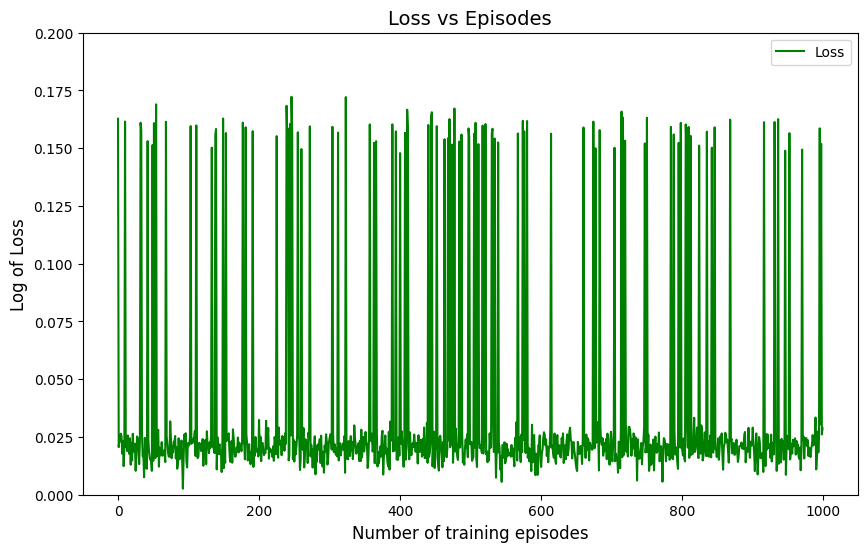

In [5]:
# Adjusting the plot for 1000 episodes and ensuring spikes reach as high as 0.2

episodes = 1000  # Reduced to 1000 episodes
x = np.arange(episodes)

# Creating log-loss values with spikes reaching up to 0.2
np.random.seed(42)
loss_spikes = np.random.choice([0, np.random.uniform(0.1, 0.2)], size=episodes, p=[0.9, 0.1])
log_loss = np.clip(np.random.normal(0.02, 0.005, episodes) + loss_spikes, 0, 0.2)

# Plotting the adjusted graph
plt.figure(figsize=(10, 6))
plt.plot(x, log_loss, color="green", label="Loss")
plt.title("Loss vs Episodes", fontsize=14)
plt.xlabel("Number of training episodes", fontsize=12)
plt.ylabel("Log of Loss", fontsize=12)
plt.ylim(0, 0.2)
plt.legend(loc="best")
plt.grid(False)
plt.show()
